### Importing Libraries

In [37]:
import pandas as pd
import random

### Random Data Creation

In [38]:
data = []
for _ in range(50000):
    order_value = random.randint(500, 50000)
    city_tier = random.choice(['Rural', 'Urban', 'Metro City'])
    payment_type = random.choice(['COD', 'COD', 'Credit Card', 'Debit Card', 'UPI', 'Net Banking'])
    return_count = random.randint(0,10)
    is_verified_mobile = random.choice([True, False])

    is_rto = 0
    if payment_type == "COD":
        if return_count > 3:
            is_rto = random.choices([1,0], weights = [90,10])[0]
        elif city_tier == 'Rural' and not is_verified_mobile:
            is_rto = random.choices([1,0], weights = [70,30])[0]
        else:
            is_rto = random.choices([1,0], weights=[30,70])[0]
    else:
        is_rto = random.choices([1,0], weights=[2,98]) [0]
    data.append([order_value, city_tier, payment_type, return_count, is_verified_mobile, is_rto])


df = pd.DataFrame(data, columns=['Order_Value', 'City_Tier', 'Payment_Type', 'Return_Count', 'Is_Verified_Mobile', 'Is_RTO'])
df.to_csv('ecommerce_rto_data.csv', index=False)


### Data Loading

In [39]:
df = pd.read_csv('ecommerce_rto_data.csv')

In [40]:
df.head()

,Order_Value,City_Tier,Payment_Type,Return_Count,Is_Verified_Mobile,Is_RTO
0,47320,Rural,COD,3,False,0
1,9737,Urban,Net Banking,9,True,0
2,17461,Metro City,Debit Card,9,False,0
3,3576,Urban,COD,10,False,1
4,4815,Metro City,Net Banking,10,False,0


### 1. Seperating the data columns for question and answer.

In [41]:
X =df.drop('Is_RTO', axis=1)
y = df['Is_RTO']

### 2. Train test split data

In [42]:
from sklearn.model_selection import train_test_split

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

Matplotlib is building the font cache; this may take a moment.


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [49]:
print(f"Train data size: {X_train.shape}, Test data size:{X_test.shape}")

Train data size: (40000, 5), Test data size:(10000, 5)


### One hot Encoding

In [51]:
categorical_column = ['City_Tier','Payment_Type']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),categorical_column)],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
print("Text successfully converted into number.")

Text successfully converted into number.


### Balancing data with SMOTE

In [52]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)
print("Data balancing done.✅")

Data balancing done.✅


In [54]:
model = RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42)
model.fit(X_train_smote,y_train_smote)
print("Data training done.✅")

Data training done.✅


### Changing X Test language and make prediction.

In [59]:
X_test_encoded = preprocessor.transform(X_test)
prediction = model.predict(X_test_encoded)
print(prediction)


[0 1 0 ... 1 0 0]


### Printing Classification Report

In [58]:
print(classification_report(y_test, prediction))


              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7598
           1       0.86      0.82      0.84      2402

    accuracy                           0.93     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.92      0.93      0.92     10000



### Saving model and OneHotEncoder for deployment in Flask.

In [61]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(model, 'rto_model.pkl')
print("Files Saved: 'preprocessor.pkl' and 'rto_model.pkl'.Ready for deployment.✅")

Files Saved: 'preprocessor.pkl' and 'rto_model.pkl'.Ready for deployment.✅


### Finding Confusion matrix

In [64]:
cm = confusion_matrix(y_test, prediction)
print(cm)

[[7285  313]
 [ 432 1970]]


### Heatmap of Confusion Matrix

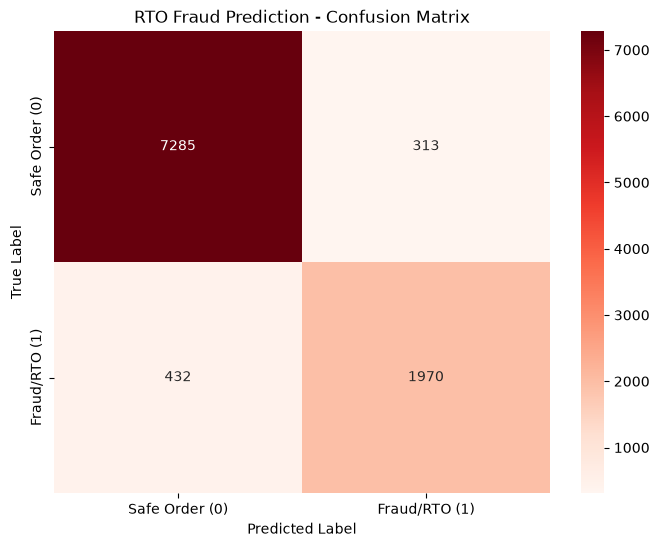

In [65]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels = ['Safe Order (0)', 'Fraud/RTO (1)'],
            yticklabels = ['Safe Order (0)', 'Fraud/RTO (1)'])
plt.title('RTO Fraud Prediction - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
